# 01: Explore PrimeKG

Exploratory data analysis of PrimeKG t0 (June 2021).

**Objectives:**
- Load and verify PrimeKG data
- Analyze node types, edge types, and their distributions
- Examine multimodal features (drug descriptions, disease descriptions)
- Visualize graph structure and statistics
- Identify potential challenges for continual learning

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from collections import Counter

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

# Load PrimeKG t0
kg = pd.read_csv('../data/benchmark/snapshots/kg_t0.csv', low_memory=False)
print(f"Shape: {kg.shape}")
print(f"Columns: {list(kg.columns)}")
kg.head()

Shape: (8100498, 10)
Columns: ['relation', 'display_relation', 'x_id', 'x_type', 'x_name', 'x_source', 'y_id', 'y_type', 'y_name', 'y_source']


,relation,display_relation,x_id,x_type,x_name,x_source,y_id,y_type,y_name,y_source
0,protein_protein,ppi,9796,gene/protein,PHYHIP,NCBI,56992,gene/protein,KIF15,NCBI
1,protein_protein,ppi,7918,gene/protein,GPANK1,NCBI,9240,gene/protein,PNMA1,NCBI
2,protein_protein,ppi,8233,gene/protein,ZRSR2,NCBI,23548,gene/protein,TTC33,NCBI
3,protein_protein,ppi,4899,gene/protein,NRF1,NCBI,11253,gene/protein,MAN1B1,NCBI
4,protein_protein,ppi,5297,gene/protein,PI4KA,NCBI,8601,gene/protein,RGS20,NCBI


## 1. Basic Statistics

In [2]:
# Node type statistics
all_node_types = set(kg['x_type'].unique()) | set(kg['y_type'].unique())
print(f"Number of node types: {len(all_node_types)}")
print(f"Node types: {sorted(all_node_types)}")
print()

# Create unified node list with integer indices
all_nodes = pd.concat([
    kg[['x_id', 'x_type', 'x_name']].rename(columns={'x_id': 'id', 'x_type': 'type', 'x_name': 'name'}),
    kg[['y_id', 'y_type', 'y_name']].rename(columns={'y_id': 'id', 'y_type': 'type', 'y_name': 'name'}),
]).drop_duplicates(subset=['id', 'type'])

print(f"Total unique nodes: {len(all_nodes):,}")
print()

# Node counts by type
node_counts = all_nodes['type'].value_counts()
print("Node counts by type:")
for ntype, count in node_counts.items():
    print(f"  {ntype}: {count:,}")
print()

# Edge statistics
print(f"Total edges: {len(kg):,}")
print(f"Number of relation types: {kg['relation'].nunique()}")
print(f"Number of display_relation types: {kg['display_relation'].nunique()}")

Number of node types: 10
Node types: ['anatomy', 'biological_process', 'cellular_component', 'disease', 'drug', 'effect/phenotype', 'exposure', 'gene/protein', 'molecular_function', 'pathway']



Total unique nodes: 129,312

Node counts by type:
  biological_process: 28,642
  gene/protein: 27,610
  disease: 17,080
  effect/phenotype: 15,311
  anatomy: 14,033
  molecular_function: 11,169
  drug: 7,957
  cellular_component: 4,176
  pathway: 2,516
  exposure: 818

Total edges: 8,100,498
Number of relation types: 30


Number of display_relation types: 18


## 2. Relation Type Distribution

Edge counts by relation type:
  anatomy_protein_present: 3,036,406
  drug_drug: 2,672,628
  protein_protein: 642,150
  disease_phenotype_positive: 300,634
  bioprocess_protein: 289,610
  cellcomp_protein: 166,804
  disease_protein: 160,822
  molfunc_protein: 139,060
  drug_effect: 129,568
  bioprocess_bioprocess: 105,772
  pathway_protein: 85,292
  disease_disease: 64,388
  contraindication: 61,350
  drug_protein: 51,306
  anatomy_protein_absent: 39,774
  phenotype_phenotype: 37,472
  anatomy_anatomy: 28,064
  molfunc_molfunc: 27,148
  indication: 18,776
  cellcomp_cellcomp: 9,690
  phenotype_protein: 6,660
  off-label use: 5,136
  pathway_pathway: 5,070
  exposure_disease: 4,608
  exposure_exposure: 4,140
  exposure_bioprocess: 3,250
  exposure_protein: 2,424
  disease_phenotype_negative: 2,386
  exposure_molfunc: 90
  exposure_cellcomp: 20


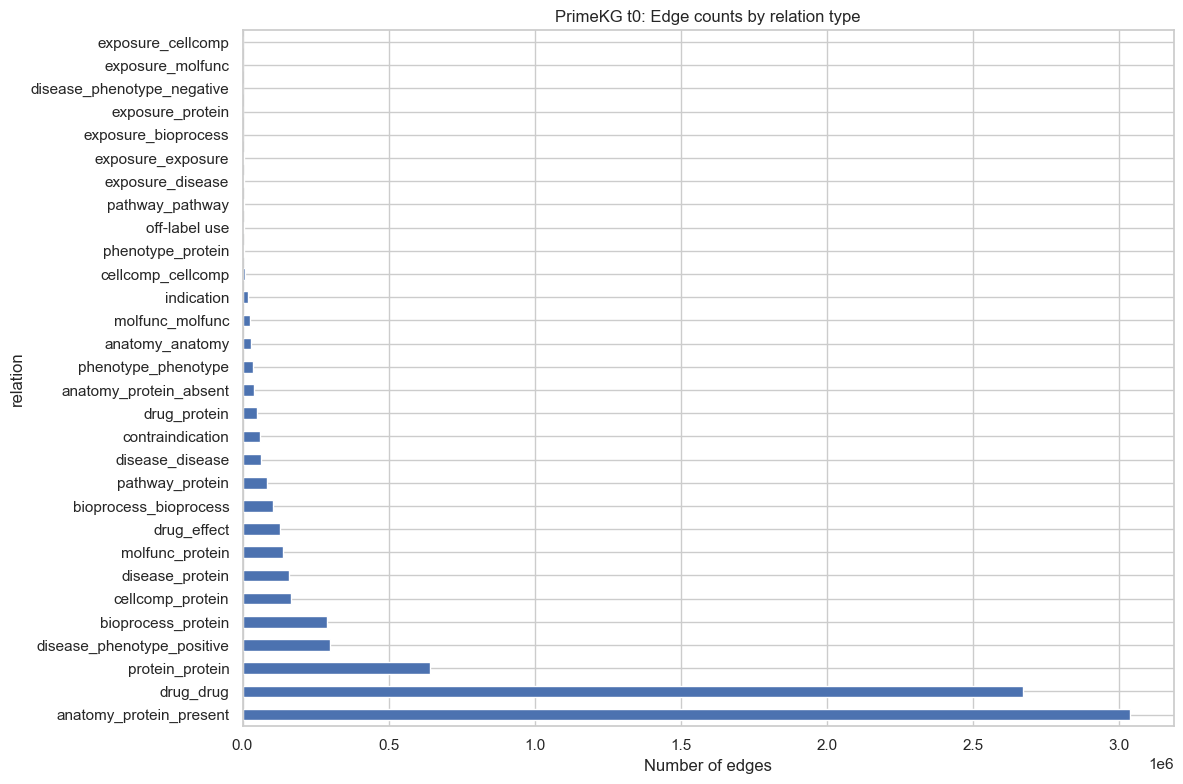

In [3]:
# Relation type counts
rel_counts = kg['relation'].value_counts()
print("Edge counts by relation type:")
for rel, count in rel_counts.items():
    print(f"  {rel}: {count:,}")

# Visualize
fig, ax = plt.subplots(figsize=(12, 8))
rel_counts.plot(kind='barh', ax=ax)
ax.set_xlabel('Number of edges')
ax.set_title('PrimeKG t0: Edge counts by relation type')
plt.tight_layout()
plt.savefig('../results/primekg_t0_relation_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Node Type Distribution

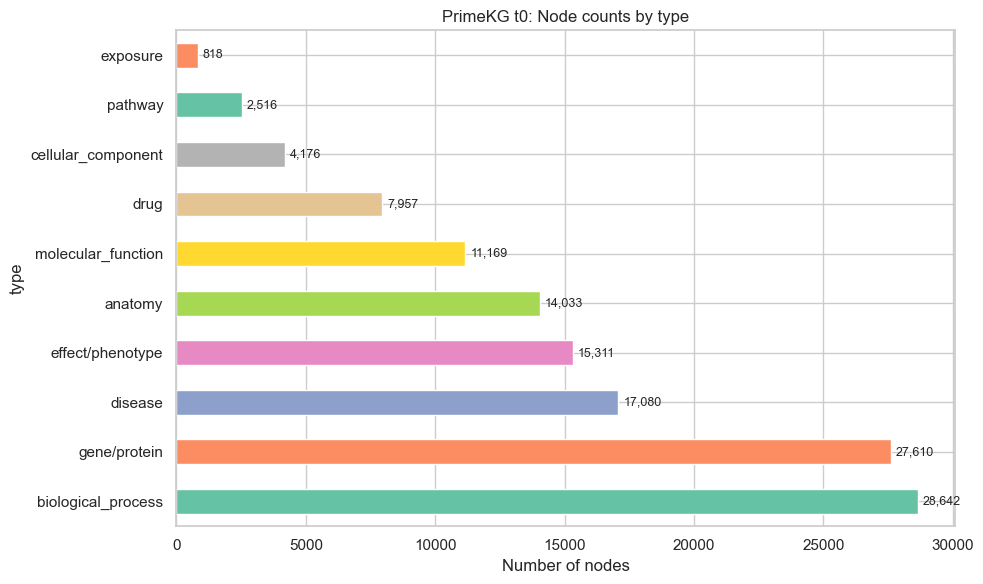

In [4]:
# Node type distribution
fig, ax = plt.subplots(figsize=(10, 6))
node_counts.plot(kind='barh', ax=ax, color=sns.color_palette('Set2', len(node_counts)))
ax.set_xlabel('Number of nodes')
ax.set_title('PrimeKG t0: Node counts by type')
for i, (count, label) in enumerate(zip(node_counts.values, node_counts.index)):
    ax.text(count + 200, i, f'{count:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../results/primekg_t0_node_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Drug-Disease Edges (Key for Link Prediction Task)

These are the edges most relevant for the continual drug-disease link prediction task.

In [5]:
# Filter drug-disease edges
drug_disease = kg[
    ((kg['x_type'] == 'drug') & (kg['y_type'] == 'disease')) |
    ((kg['x_type'] == 'disease') & (kg['y_type'] == 'drug'))
]

print(f"Drug-Disease edges: {len(drug_disease):,}")
print(f"Unique drugs involved: {len(set(drug_disease.loc[drug_disease['x_type']=='drug', 'x_id']) | set(drug_disease.loc[drug_disease['y_type']=='drug', 'y_id'])):,}")
print(f"Unique diseases involved: {len(set(drug_disease.loc[drug_disease['x_type']=='disease', 'x_id']) | set(drug_disease.loc[drug_disease['y_type']=='disease', 'y_id'])):,}")
print()

# Relation types in drug-disease edges
print("Drug-disease relation types:")
dd_rels = drug_disease['display_relation'].value_counts()
for rel, count in dd_rels.items():
    print(f"  {rel}: {count:,}")

print()
# Sample drug-disease edges
print("Sample drug-disease edges:")
drug_disease.head(10)

Drug-Disease edges: 85,262
Unique drugs involved: 2,074
Unique diseases involved: 2,054

Drug-disease relation types:
  contraindication: 61,350
  indication: 18,776
  off-label use: 5,136

Sample drug-disease edges:


,relation,display_relation,x_id,x_type,x_name,x_source,y_id,y_type,y_name,y_source
346728,contraindication,contraindication,DB05271,drug,Rotigotine,DrugBank,5044,disease,hypertensive disorder,MONDO
346729,contraindication,contraindication,DB05271,drug,Rotigotine,DrugBank,1200_1134_15512_5080_100078,disease,hypertension,MONDO_grouped
346730,indication,indication,DB00492,drug,Fosinopril,DrugBank,5044,disease,hypertensive disorder,MONDO
346731,indication,indication,DB00492,drug,Fosinopril,DrugBank,1200_1134_15512_5080_100078,disease,hypertension,MONDO_grouped
346732,contraindication,contraindication,DB13956,drug,Estradiol valerate,DrugBank,5044,disease,hypertensive disorder,MONDO
346733,contraindication,contraindication,DB13956,drug,Estradiol valerate,DrugBank,1200_1134_15512_5080_100078,disease,hypertension,MONDO_grouped
346734,contraindication,contraindication,DB01438,drug,Phenazopyridine,DrugBank,5044,disease,hypertensive disorder,MONDO
346735,contraindication,contraindication,DB01438,drug,Phenazopyridine,DrugBank,1200_1134_15512_5080_100078,disease,hypertension,MONDO_grouped
346736,contraindication,contraindication,DB09203,drug,Synephrine,DrugBank,5044,disease,hypertensive disorder,MONDO
346737,contraindication,contraindication,DB09203,drug,Synephrine,DrugBank,1200_1134_15512_5080_100078,disease,hypertension,MONDO_grouped


## 5. Drug Features (Multimodal Data)

In [6]:
# Load drug features from TDC
drug_features = pd.read_csv('../data/benchmark/snapshots/drug_features_t0.csv', low_memory=False)
print(f"Drug features shape: {drug_features.shape}")
print(f"Columns: {list(drug_features.columns)}")
print()

# Check which text fields are available
for col in drug_features.columns:
    non_null = drug_features[col].notna().sum()
    pct = non_null / len(drug_features) * 100
    print(f"  {col}: {non_null:,} non-null ({pct:.1f}%)")

print()
# Show a sample
drug_features.head(3)

Drug features shape: (7957, 18)
Columns: ['node_index', 'description', 'half_life', 'indication', 'mechanism_of_action', 'protein_binding', 'pharmacodynamics', 'state', 'atc_1', 'atc_2', 'atc_3', 'atc_4', 'category', 'group', 'pathway', 'molecular_weight', 'tpsa', 'clogp']

  node_index: 7,957 non-null (100.0%)
  description: 4,591 non-null (57.7%)
  half_life: 2,063 non-null (25.9%)
  indication: 3,393 non-null (42.6%)
  mechanism_of_action: 3,242 non-null (40.7%)
  protein_binding: 1,665 non-null (20.9%)
  pharmacodynamics: 2,659 non-null (33.4%)
  state: 6,517 non-null (81.9%)
  atc_1: 2,818 non-null (35.4%)
  atc_2: 2,818 non-null (35.4%)
  atc_3: 2,818 non-null (35.4%)
  atc_4: 2,818 non-null (35.4%)
  category: 5,431 non-null (68.3%)
  group: 7,957 non-null (100.0%)
  pathway: 598 non-null (7.5%)
  molecular_weight: 2,797 non-null (35.2%)
  tpsa: 2,718 non-null (34.2%)
  clogp: 2,574 non-null (32.3%)



,node_index,description,half_life,indication,mechanism_of_action,protein_binding,pharmacodynamics,state,atc_1,atc_2,atc_3,atc_4,category,group,pathway,molecular_weight,tpsa,clogp
0,14012,Copper is a transition metal and a trace eleme...,NaN,For use in the supplementation of total parent...,Copper is absorbed from the gut via high affin...,Copper is nearly entirely bound by ceruloplasm...,Copper is incorporated into many enzymes throu...,Copper is a solid.,NaN,NaN,NaN,NaN,Copper is part of Copper-containing Intrauteri...,Copper is approved and investigational.,NaN,NaN,NaN,NaN
1,14013,Oxygen is an element displayed by the symbol O...,The half-life is approximately 122.24 seconds,Oxygen therapy in clinical settings is used ac...,Oxygen therapy increases the arterial pressure...,Oxygen binds to oxygen-carrying protein in red...,Oxygen therapy improves effective cellular oxy...,Oxygen is a gas.,Oxygen is anatomically related to various.,Oxygen is in the therapeutic group of all othe...,Oxygen is pharmacologically related to all oth...,The chemical and functional group of is medic...,Oxygen is part of Chalcogens ; Elements ; Gase...,Oxygen is approved and vet_approved.,NaN,The molecular weight is 32.0.,Oxygen has a topological polar surface area of...,NaN
2,14014,"Flunisolide (marketed as AeroBid, Nasalide, Na...",The half-life is 1.8 hours,For the maintenance treatment of asthma as a p...,Flunisolide is a glucocorticoid receptor agoni...,Approximately 40% after oral inhalation,Flunisolide is a synthetic corticosteroid. It ...,Flunisolide is a solid.,Flunisolide is anatomically related to respira...,Flunisolide is in the therapeutic group of nas...,Flunisolide is pharmacologically related to de...,The chemical and functional group of is corti...,Flunisolide is part of Adrenal Cortex Hormones...,Flunisolide is approved and investigational.,NaN,The molecular weight is 434.5.,Flunisolide has a topological polar surface ar...,The log p value of is 2.41.


## 6. Edge Type Cross-Tabulation (which node types connect to which?)

Edge cross-tabulation (x_type vs y_type):
y_type              anatomy  biological_process  cellular_component  disease     drug  effect/phenotype  exposure  gene/protein  molecular_function  pathway
x_type                                                                                                                                                      
anatomy               28064                   0                   0        0        0                 0         0       1538090                   0        0
biological_process        0              105772                   0        0        0                 0      1625        144805                   0        0
cellular_component        0                   0                9690        0        0                 0        10         83402                   0        0
disease                   0                   0                   0    64388    42631            151510      2304         80411                   0        0
drug            

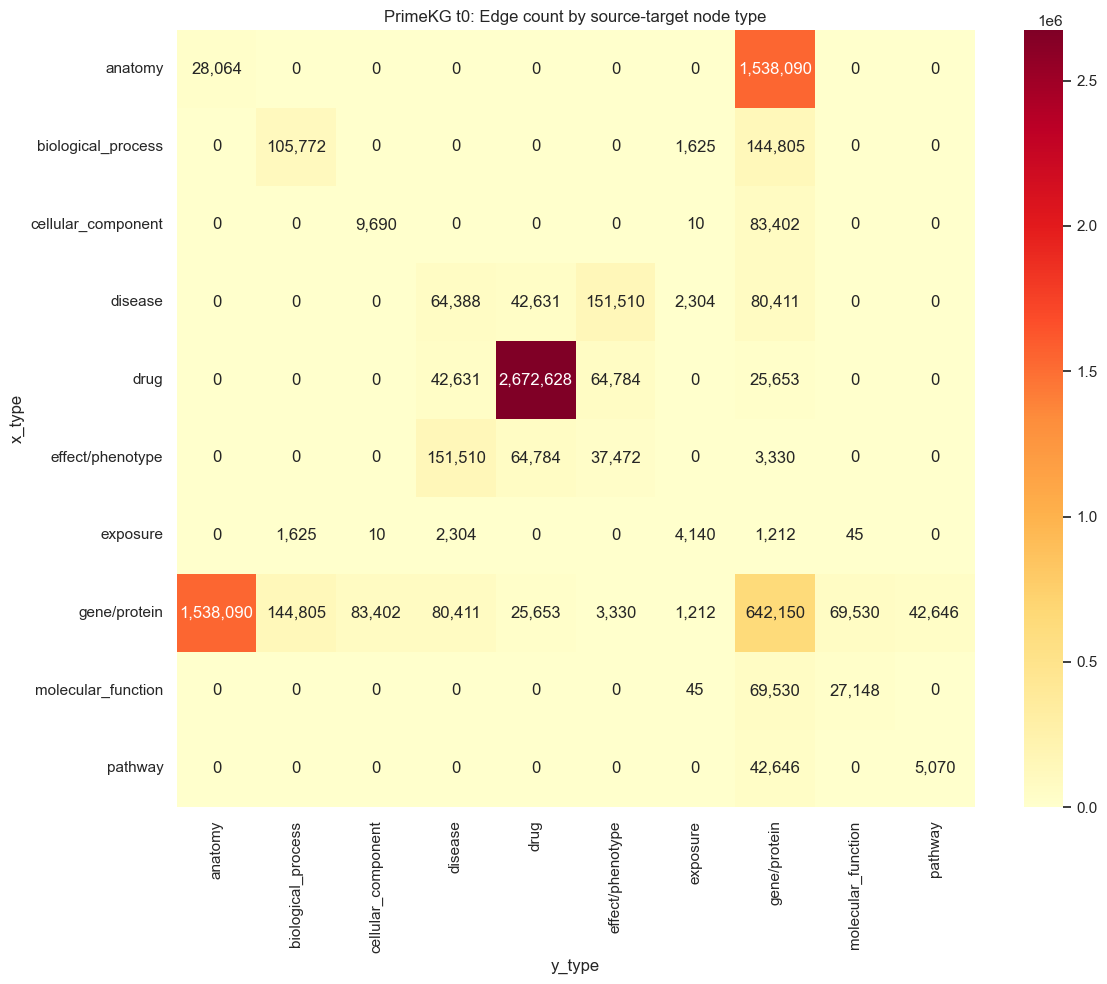

In [7]:
# Cross-tabulation: which node types connect to which?
cross_tab = pd.crosstab(kg['x_type'], kg['y_type'])
print("Edge cross-tabulation (x_type vs y_type):")
print(cross_tab.to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cross_tab, annot=True, fmt=',', cmap='YlOrRd', ax=ax)
ax.set_title('PrimeKG t0: Edge count by source-target node type')
plt.tight_layout()
plt.savefig('../results/primekg_t0_edge_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Summary

Key findings for the MCGL project from PrimeKG t0 exploration.

In [8]:
# Summary statistics
from src.data.download import verify_primekg

stats = verify_primekg(kg, expected_snapshot='t0')

print("=" * 60)
print("PrimeKG t0 Summary")
print("=" * 60)
print(f"Total edges:         {stats['num_rows']:>12,}")
print(f"Total columns:       {stats['num_columns']:>12}")
print(f"Node types:          {stats.get('num_node_types', '?'):>12}")
print(f"Relation types:      {stats.get('num_relation_types', '?'):>12}")
print(f"Drug-Disease edges:  {len(drug_disease):>12,}")
print(f"Drug features cols:  {len(drug_features.columns):>12}")
print(f"Verification:        {stats['status']:>12}")
if stats['issues']:
    print(f"\nIssues: {stats['issues']}")
print("=" * 60)
print("\nNotes for Phase 2 (Benchmark Construction):")
print("- TDC version lacks x_index/y_index columns (need to create integer node mapping)")
print("- Drug features available from TDC (description, indication, pharmacodynamics, etc.)")
print("- Drug-disease edges are the primary target for link prediction task")
print("- 30 relation types available for relation_type-based task sequencing")

PrimeKG t0 Summary
Total edges:            8,100,498
Total columns:                 10
Node types:                    10
Relation types:                30
Drug-Disease edges:        85,262
Drug features cols:            18
Verification:        ISSUES_FOUND

Issues: ["Missing columns: {'x_index', 'y_index'}"]

Notes for Phase 2 (Benchmark Construction):
- TDC version lacks x_index/y_index columns (need to create integer node mapping)
- Drug features available from TDC (description, indication, pharmacodynamics, etc.)
- Drug-disease edges are the primary target for link prediction task
- 30 relation types available for relation_type-based task sequencing
